In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [142]:
df = pd.read_csv("public_transport_delays.csv")

In [143]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [144]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [145]:
df.duplicated().sum()

np.int64(0)

In [146]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [147]:
len(df)

2000

In [148]:
c = df.groupby('event_type')['event_type'].count()
c

event_type
Concert     203
Festival    221
Parade      105
Protest      86
Sports      212
Name: event_type, dtype: int64

In [149]:
df['event_type'].unique()

<StringArray>
[nan, 'Sports', 'Protest', 'Parade', 'Concert', 'Festival']
Length: 6, dtype: str

In [150]:
df['event_type'] = df['event_type'].fillna("NO Event")

In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [152]:
pd.to_datetime(df['date'])
pd.to_datetime(df['time'])

C:\Users\praka\AppData\Local\Temp\ipykernel_21332\818874788.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['time'])


0      2026-04-03 05:00:00
1      2026-04-03 05:15:00
2      2026-04-03 05:30:00
3      2026-04-03 05:45:00
4      2026-04-03 06:00:00
               ...        
1995   2026-04-03 23:45:00
1996   2026-04-03 00:00:00
1997   2026-04-03 00:15:00
1998   2026-04-03 00:30:00
1999   2026-04-03 00:45:00
Name: time, Length: 2000, dtype: datetime64[us]

In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [154]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [155]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NO Event,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NO Event,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NO Event,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NO Event,500,46,0,0,6,Spring,1


In [156]:
df.isnull().sum()

trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
dtype: int64

In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [158]:
df['weather_condition'].unique()

<StringArray>
['Storm', 'Rain', 'Clear', 'Snow', 'Fog', 'Cloudy']
Length: 6, dtype: str

In [159]:
df['season'].unique()

<StringArray>
['Winter', 'Autumn', 'Spring', 'Summer']
Length: 4, dtype: str

In [160]:
a = df.groupby('actual_arrival_delay_min')['actual_arrival_delay_min'].count()
a

actual_arrival_delay_min
-3     55
-2     61
-1     49
 0     55
 1     50
 2     57
 3     55
 4     62
 5     57
 6     58
 7     49
 8     45
 9     65
 10    76
 11    84
 12    64
 13    66
 14    67
 15    62
 16    69
 17    66
 18    66
 19    64
 20    51
 21    53
 22    58
 23    69
 24    75
 25    56
 26    61
 27    63
 28    65
 29    47
Name: actual_arrival_delay_min, dtype: int64

In [161]:
df['peak_hour'].head(15)

0     1
1     0
2     0
3     0
4     0
5     0
6     1
7     0
8     0
9     0
10    0
11    0
12    0
13    1
14    0
Name: peak_hour, dtype: int64

In [162]:
df['peak_hour'] = df['peak_hour'].replace({1: 'peak', 0: "non-Peak"})


In [163]:
df['peak_hour'].head()

0        peak
1    non-Peak
2    non-Peak
3    non-Peak
4    non-Peak
Name: peak_hour, dtype: object

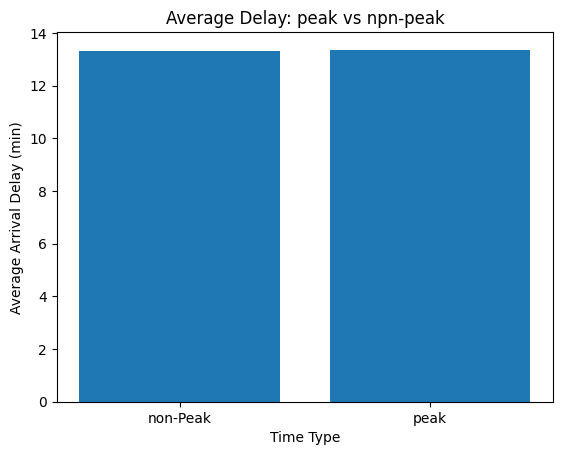

In [164]:
avg_delay = df.groupby('peak_hour')['actual_arrival_delay_min'].mean()
plt.bar(['non-Peak', 'peak'], avg_delay)
plt.xlabel('Time Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay: peak vs npn-peak')
plt.show()

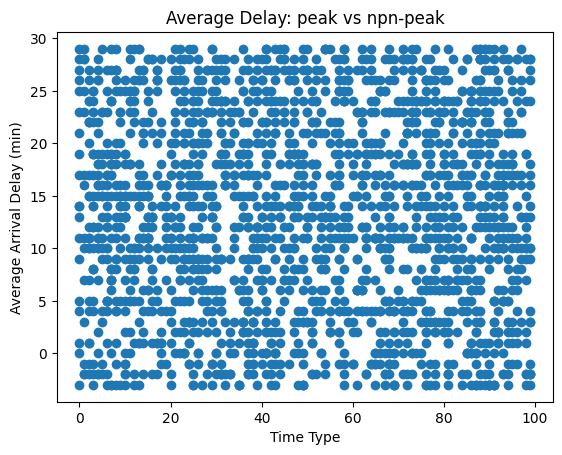

In [165]:
# avg_delay = df.groupby('peak_hour')['actual_arrival_delay_min'].mean()
# plt.bar(['non-Peak', 'peak'], avg_delay
plt.scatter(df['traffic_congestion_index'], df['actual_arrival_delay_min'])
plt.xlabel('Time Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay: peak vs npn-peak')
plt.show()

In [166]:
df['traffic_level'] = pd.cut(df['traffic_congestion_index'],
                                       bins=[0, 20, 40, 60, 80, 100],
                                       labels=['low', 'medium', 'high', 'very_high', 'extreme'])

In [167]:
df['traffic_level'].head()

0      extreme
1         high
2    very_high
3      extreme
4         high
Name: traffic_level, dtype: category
Categories (5, str): ['low' < 'medium' < 'high' < 'very_high' < 'extreme']

In [172]:
avg_delay = df.groupby('traffic_level')['actual_arrival_delay_min'].mean()

<BarContainer object of 5 artists>

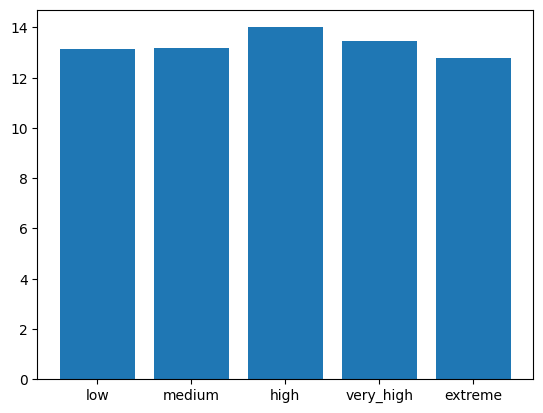

In [178]:
plt.bar(avg_delay.index, avg_delay.values) 

In [193]:
weather_delay = df.groupby('weather_condition')['actual_arrival_delay_min'].mean()

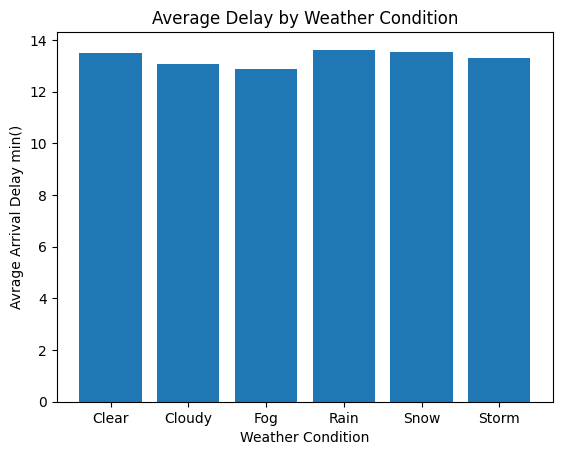

In [198]:
plt.bar(weather_delay.index, weather_delay.values)
plt.title('Average Delay by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Avrage Arrival Delay min()')
plt.show()